# Experiment 7 — AISO-GNN Unified: Feature Selection + Subgraph Sampling

## 핵심 이론
$$P(S, F) = P(S \mid F) \cdot P(F)$$

- $P(F)$: AISO가 feat_mask를 최적화 (feature type vector W_i)  
- $P(S \mid F)$: 선택된 피처 관점에서 illicit 노드를 스코어링 → 서브그래프

## Exp 1b vs Exp 5 vs Exp 7

| | 특징 선택 | 노드 샘플링 | 위상 인지 | GNN |
|---|---|---|---|---|
| Exp 1b | Dom-12 (수동) | AISO 기반 | △ (수동 설계) | ✓ |
| Exp 5 | AISO 자동 | N/A (tabular only) | X | X |
| **Exp 7 (Ours)** | **AISO 자동** | **Feature-Conditioned** | **O (f94-f164 활용)** | **✓** |

**핵심 기여**: Dom-12 수동 설계 완전 제거 → End-to-End 자동화

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import copy
import matplotlib.pyplot as plt
from pathlib import Path

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE   = Path(r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset')

K_SELECT  = 20      # AISO가 선택할 피처 수
N_TYPES   = 15      # 피처 클러스터 수 (Exp 5 동일)
SEEDS     = [0, 7, 42, 77, 123]
GAMMA     = 0.5
N_ILLICIT = 1000    # 서브그래프에 포함할 illicit 노드 수
N_LICIT   = 10000   # 고정 licit pool (Exp 1b 동일)
SPLIT_T   = 34      # train/test 시간 분할
GNN_SEED  = 42
TOP_K_FIDELITY = 5  # 시드당 Spearman 데이터용 상위 K 마스크

BASELINE_DOM12  = 0.6041   # Exp 1b: AISO(Dom-12) mean PR-AUC
BASELINE_STD12  = 0.0250

print(f'Device: {DEVICE}')
print(f'K_SELECT={K_SELECT}, N_TYPES={N_TYPES}, N_ILLICIT={N_ILLICIT}')

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
K_SELECT=20, N_TYPES=15, N_ILLICIT=1000


---
## 1. 데이터 로드

In [2]:
print('데이터 로딩 중...')
feat_df = pd.read_csv(BASE / 'elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(BASE / 'elliptic_txs_classes.csv')
edge_df = pd.read_csv(BASE / 'elliptic_txs_edgelist.csv')

feat_df.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(165)]
cls_df.columns  = ['txId', 'class']

df      = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['label'] = (labeled['class'] == '1').astype(int)

feat_cols = [f'f{i}' for i in range(165)]
X_raw  = labeled[feat_cols].values.astype(float)
y_all  = labeled['label'].values
ts_all = labeled['timestep'].values
N_NODES = len(labeled)
txid_to_idx = {txid: i for i, txid in enumerate(labeled['txId'].values)}

# ── 엣지 배열 ────────────────────────────────────────────────
e_s  = edge_df['txId1'].map(txid_to_idx)
e_d  = edge_df['txId2'].map(txid_to_idx)
valid = e_s.notna() & e_d.notna()
s_arr = e_s[valid].astype(int).values
d_arr = e_d[valid].astype(int).values
msk   = (s_arr < N_NODES) & (d_arr < N_NODES)
src_arr, dst_arr = s_arr[msk], d_arr[msk]

# 양방향 edge_index (GNN용)
src_bi = np.concatenate([src_arr, dst_arr])
dst_bi = np.concatenate([dst_arr, src_arr])
edge_index = torch.tensor([src_bi, dst_bi], dtype=torch.long)
ei_np = edge_index.numpy()

# ── Train / Test 분할 ─────────────────────────────────────────
train_mask = ts_all <= SPLIT_T
test_mask  = ts_all >  SPLIT_T
train_illicit_idx = np.where(train_mask & (y_all == 1))[0]
train_licit_idx   = np.where(train_mask & (y_all == 0))[0]

# StandardScaler (GNN 입력용 — Exp 1b 동일)
X_scaled = StandardScaler().fit_transform(X_raw)

# Illicit pool: train_illicit_idx 순서 유지 (evaluate_gnn 인덱스 매핑)
X_illicit_pool = X_scaled[train_illicit_idx]   # (N_illicit_train, 165)

# 학습 노드 전체 (AISO proxy 학습용)
X_tr_all = X_scaled[train_mask]
y_tr_all = y_all[train_mask]

# 고정 licit pool — Exp 1b와 동일 (seed=42, N=10,000)
sel_n   = np.random.RandomState(GNN_SEED).choice(train_licit_idx, N_LICIT, replace=False)
_LOOKUP = np.full(N_NODES, -1, dtype=np.int32)

print(f'노드: {N_NODES:,}  엣지(단방향): {len(src_arr):,}  양방향: {len(src_bi):,}')
print(f'Train illicit: {len(train_illicit_idx):,}  licit: {len(train_licit_idx):,}')
print(f'Test 노드: {test_mask.sum():,}')
print(f'X_illicit_pool: {X_illicit_pool.shape}')

데이터 로딩 중...


C:\Users\kevin\AppData\Local\Temp\ipykernel_38744\2966155433.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([src_bi, dst_bi], dtype=torch.long)


노드: 46,564  엣지(단방향): 36,624  양방향: 73,248
Train illicit: 3,462  licit: 26,432
Test 노드: 16,670
X_illicit_pool: (3462, 165)


---
## 2. Smart M 구성 (Exp 5 재사용)

$$M[i][j] = -\overline{|C[\text{cl}_i, \text{cl}_j]|} + \gamma(\overline{MI}_j - \overline{MI}_i)$$

f94~f164 (aggregated 피처)가 1-hop 이웃 집계 통계를 내포 → Smart M이 위상 인지 클러스터를 자동 발견

In [3]:
print('피처 클러스터링 중...')
C_full = np.corrcoef(X_tr_all.T)
C_abs  = np.abs(C_full)
dist_matrix = 1.0 - C_abs
np.fill_diagonal(dist_matrix, 0.0)

clustering = AgglomerativeClustering(
    n_clusters=N_TYPES, metric='precomputed', linkage='average'
)
cluster_labels = clustering.fit_predict(dist_matrix)
print(f'클러스터 크기: {sorted(np.bincount(cluster_labels).tolist())}')

print('MI 계산 중...')
MI_global = mutual_info_classif(X_tr_all, y_tr_all, random_state=42)
print(f'MI range: [{MI_global.min():.4f}, {MI_global.max():.4f}]')

# f94~f164 클러스터 분포 확인 (위상 피처 인식)
agg_feat_idx = list(range(94, 165))
agg_clusters = cluster_labels[agg_feat_idx]
print(f'f94~f164 클러스터 분포: {dict(zip(*np.unique(agg_clusters, return_counts=True)))}')


def build_M(mode='smart'):
    K = N_TYPES
    M = np.zeros((K, K))
    mean_MI = np.array([
        MI_global[cluster_labels == k].mean()
        if (cluster_labels == k).any() else 0.0
        for k in range(K)
    ])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)
    for i in range(K):
        for j in range(K):
            fi = np.where(cluster_labels == i)[0]
            fj = np.where(cluster_labels == j)[0]
            if i == j:
                M[i][j] = -1.0
            else:
                corr_pen = -np.mean(C_abs[np.ix_(fi, fj)])
                if mode == 'smart':
                    # 비대칭: MI 높은 j가 낮은 i를 유인 (c_ij ≠ c_ji 유지)
                    M[i][j] = corr_pen + GAMMA * (MI_norm[j] - MI_norm[i])
                else:
                    M[i][j] = corr_pen
    return M


M_smart = build_M('smart')
M_corr  = build_M('corr')
print(f'\nM_smart 비대칭: M[0,1]={M_smart[0,1]:.3f}, M[1,0]={M_smart[1,0]:.3f}')

피처 클러스터링 중...
클러스터 크기: [1, 1, 2, 2, 3, 4, 4, 5, 8, 8, 10, 14, 17, 22, 64]
MI 계산 중...
MI range: [0.0012, 0.2303]
f94~f164 클러스터 분포: {np.int64(0): np.int64(13), np.int64(1): np.int64(2), np.int64(2): np.int64(4), np.int64(3): np.int64(10), np.int64(4): np.int64(4), np.int64(6): np.int64(21), np.int64(8): np.int64(7), np.int64(9): np.int64(8), np.int64(10): np.int64(2)}

M_smart 비대칭: M[0,1]=-0.320, M[1,0]=0.232


---
## 3. GCN + evaluate_gnn (Exp 1b 완전 동일 프로토콜)

In [4]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


def evaluate_gnn(top_n_illicit_local, label='', gnn_seed=GNN_SEED):
    """
    Transductive GNN evaluation — Exp 1b 동일 프로토콜.
    top_n_illicit_local: train_illicit_idx 로컬 인덱스
    GNN 입력: X_scaled (165 features) — 공정 비교
    """
    uniq            = np.unique(top_n_illicit_local)
    sel_anom_global = train_illicit_idx[uniq]
    test_global     = np.where(test_mask)[0]

    sub_nodes = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
    n_sub = len(sub_nodes)

    _LOOKUP[:] = -1
    _LOOKUP[sub_nodes] = np.arange(n_sub)
    src_loc = _LOOKUP[ei_np[0]]
    dst_loc = _LOOKUP[ei_np[1]]
    ok     = (src_loc >= 0) & (dst_loc >= 0)
    sub_ei = torch.tensor([src_loc[ok], dst_loc[ok]], dtype=torch.long).to(DEVICE)

    sub_X = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
    sub_y = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)

    train_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
    test_set  = set(test_global.tolist())
    tr_gnn = torch.tensor([g in train_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    te_gnn = torch.tensor([g in test_set  for g in sub_nodes], dtype=torch.bool).to(DEVICE)

    y_tr_sub = y_all[sub_nodes][tr_gnn.cpu().numpy()]
    n0 = int((y_tr_sub == 0).sum()); n1 = int((y_tr_sub == 1).sum())
    cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

    torch.manual_seed(gnn_seed)
    model = GCN(X_scaled.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_loss, best_state, patience = float('inf'), None, 0
    for ep in range(200):
        model.train(); opt.zero_grad()
        out  = model(sub_X, sub_ei)
        loss = F.cross_entropy(out[tr_gnn], sub_y[tr_gnn], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss  = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience   = 0
        else:
            patience += 1
        if patience >= 20:
            break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob = F.softmax(model(sub_X, sub_ei), dim=1)[:, 1].cpu().numpy()

    te_cpu = te_gnn.cpu().numpy()
    res = {
        'PR-AUC': average_precision_score(y_all[sub_nodes][te_cpu], prob[te_cpu]),
        'F1':     f1_score(y_all[sub_nodes][te_cpu],
                           (prob >= 0.5).astype(int)[te_cpu], zero_division=0),
        'AUC':    roc_auc_score(y_all[sub_nodes][te_cpu], prob[te_cpu]),
    }
    if label:
        print(f'  {label:<40} PR-AUC={res["PR-AUC"]:.4f}  '
              f'F1={res["F1"]:.4f}  AUC={res["AUC"]:.4f}')
    return res


print('GCN + evaluate_gnn 준비 완료')
print(f'  sel_n={len(sel_n):,}  edge_index={edge_index.shape[1]:,}  GNN seed={GNN_SEED}')

GCN + evaluate_gnn 준비 완료
  sel_n=10,000  edge_index=73,248  GNN seed=42


---
## 4. Logging 구조 + Diversity / Compute Cost 유틸

### 로그 항목 (논문 데이터용)
| 로그 | 항목 |
|------|------|
| proxy_evals | feat_mask, sgd_auc, cache_hit, eval_time, generation, agent_id |
| diversity_log | generation, mask_jaccard_mean, node_jaccard_mean, coverage_entropy, n_unique_masks |
| gnn_evals | feat_mask, top_n_nodes, proxy_auc, gnn_pr_auc, gnn_eval_time, overlap_ratio |
| timing | total_search_time, total_proxy_time, total_gnn_time, cache_hit_ratio |

### GNN Budget
generation 단위로 top-K만 GNN 평가 → 총 `gnn_budget` 회 이하로 고정

In [5]:
import time

GNN_BUDGET     = 5   # 시드당 GNN 평가 횟수 상한 (총 5 seeds x 2 methods = 50 GNN calls)
DIV_INTERVAL   = 20  # diversity 로깅 주기 (iteration)


# ── Diversity 유틸 ──────────────────────────────────────────────

def mask_jaccard(masks):
    """에이전트 mask 쌍별 Jaccard 평균 → feature exploration 다양성"""
    if len(masks) < 2:
        return 0.0
    vals = []
    for i in range(len(masks)):
        for j in range(i + 1, len(masks)):
            si, sj = set(masks[i]), set(masks[j])
            vals.append(len(si & sj) / max(len(si | sj), 1))
    return float(np.mean(vals))


def node_jaccard(node_lists):
    """서브그래프 쌍별 Jaccard 평균 → subgraph exploration 다양성"""
    if len(node_lists) < 2:
        return 0.0
    vals = []
    for i in range(len(node_lists)):
        for j in range(i + 1, len(node_lists)):
            si, sj = set(node_lists[i]), set(node_lists[j])
            vals.append(len(si & sj) / max(len(si | sj), 1))
    return float(np.mean(vals))


def coverage_entropy(node_lists, n_total):
    """선택된 노드의 빈도 분포 엔트로피 → illicit pool 커버리지"""
    if not node_lists:
        return 0.0
    freq = np.zeros(n_total)
    for nl in node_lists:
        np.add.at(freq, nl, 1)
    p = freq / max(freq.sum(), 1)
    p = p[p > 0]
    return float(-np.sum(p * np.log(p + 1e-10)))


def overlap_ratio(mask_a, mask_b):
    """두 mask 간 겹치는 피처 비율 |A∩B|/|A∪B|"""
    sa, sb = set(mask_a), set(mask_b)
    return len(sa & sb) / max(len(sa | sb), 1)


# ── AISOwrapperGNN ──────────────────────────────────────────────

class AISOwrapperGNN:
    """
    P(S,F) = P(S|F)·P(F) 통합 최적화.

    로그:
      run_log['proxy_evals']  : 모든 proxy 평가 엔트리
      run_log['diversity_log']: DIV_INTERVAL 주기 다양성 메트릭
      run_log['timing']       : compute cost 요약
      fidelity_cands          : GNN budget 평가용 후보 목록
    """

    def __init__(self, n_agents=20, n_iter=80, beta=0.15,
                 subsample_ratio=0.15, val_ratio=0.2,
                 T_start=1.0, T_end=0.05,
                 n_illicit=1000, gnn_budget=GNN_BUDGET,
                 div_interval=DIV_INTERVAL):
        self.n_agents        = n_agents
        self.n_iter          = n_iter
        self.beta            = beta
        self.subsample_ratio = subsample_ratio
        self.val_ratio       = val_ratio
        self.T_start         = T_start
        self.T_end           = T_end
        self.n_illicit       = n_illicit
        self.gnn_budget      = gnn_budget
        self.div_interval    = div_interval

    def select(self, X_tr, y_tr, X_illicit_pool, cluster_labels, K_select, M,
               seed=42, method_name=''):
        rng = np.random.RandomState(seed)
        N, D = X_tr.shape
        K  = M.shape[0]
        nb = min(3, self.n_agents - 1)
        n_illicit_total = len(X_illicit_pool)

        # ── Log 초기화 ─────────────────────────────────────────
        run_log = {
            'method': method_name,
            'seed':   seed,
            'proxy_evals': [],   # per-eval entries
            'diversity_log': [], # per-checkpoint
            'timing': {
                'proxy_times': [],
                'total_start': time.time(),
            },
        }

        # ── Train / val split ──────────────────────────────────
        val_n   = int(self.val_ratio * N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X_tr[val_idx], y_tr[val_idx]
        X_t,   y_t   = X_tr[tr_mask],  y_tr[tr_mask]
        sub_n = max(50, int(self.subsample_ratio * len(X_t)))

        # ── Cache ──────────────────────────────────────────────
        cache   = {}   # mask_key → {proxy_auc, illicit_scores}
        n_calls = [0]

        def get_mask(Wi, t, explore=True):
            if explore:
                ratio  = t / max(1, self.n_iter - 1)
                T      = self.T_start * ((self.T_end / self.T_start) ** ratio)
                logits = Wi[cluster_labels] / T
                logits -= logits.max()
                probs  = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            else:
                return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mask_key, X_sub, y_sub, generation, agent_id):
            n_calls[0] += 1
            hit = mask_key in cache
            t0  = time.time()

            if not hit:
                feat = list(mask_key)
                sgd  = SGDClassifier(loss='log_loss', max_iter=5, tol=None,
                                      class_weight='balanced', random_state=seed)
                try:
                    sgd.fit(X_sub[:, feat], y_sub)
                    val_proba     = sgd.predict_proba(X_val[:, feat])[:, 1]
                    proxy_auc     = roc_auc_score(y_val, val_proba)
                    illicit_proba = sgd.predict_proba(X_illicit_pool[:, feat])[:, 1]
                except Exception:
                    proxy_auc     = 0.5
                    illicit_proba = rng.rand(n_illicit_total)
                cache[mask_key] = {'proxy_auc': proxy_auc,
                                   'illicit_scores': illicit_proba}

            elapsed = time.time() - t0
            run_log['timing']['proxy_times'].append(elapsed)

            entry = {
                'generation':  generation,
                'agent_id':    agent_id,
                'feat_mask':   tuple(sorted(mask_key)),
                'sgd_auc':     cache[mask_key]['proxy_auc'],
                'cache_hit':   hit,
                'eval_time':   elapsed,
            }
            run_log['proxy_evals'].append(entry)
            return cache[mask_key]['proxy_auc']

        def top_n_from_cache(mask_key):
            scores = cache[mask_key]['illicit_scores']
            return np.argsort(scores)[-self.n_illicit:]

        # ── 초기화 ─────────────────────────────────────────────
        W      = rng.dirichlet(np.ones(K), self.n_agents)
        scores = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            mk  = get_mask(W[i], 0)
            scores[i] = get_score(mk, X_t[sub], y_t[sub], generation=0, agent_id=i)

        # ── 메인 루프 ──────────────────────────────────────────
        for t in range(self.n_iter):
            Cm = W @ M @ W.T
            np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]

            for i in range(self.n_agents):
                att        = np.argsort(Cm[i])[-nb:]
                att_scores = np.array([
                    get_score(get_mask(W[j], t), X_sub, y_sub,
                              generation=t, agent_id=j)
                    for j in att
                ])
                max_s = att_scores.max() + 1e-8
                bj    = att[np.argmax(Cm[i, att] * att_scores / max_s)]
                W_new = (1 - self.beta) * W[i] + self.beta * W[bj]
                W[i]  = W_new / W_new.sum()
                scores[i] = get_score(get_mask(W[i], t), X_sub, y_sub,
                                       generation=t, agent_id=i)

            # ── Diversity 체크포인트 ────────────────────────────
            if t % self.div_interval == 0 or t == self.n_iter - 1:
                cur_masks     = [get_mask(W[i], t, explore=False)
                                 for i in range(self.n_agents)]
                cached_masks  = [mk for mk in cur_masks if mk in cache]
                node_lists    = [list(top_n_from_cache(mk)) for mk in cached_masks]

                mk_j  = mask_jaccard(cur_masks)
                nd_j  = node_jaccard(node_lists)
                cov_e = coverage_entropy(node_lists, n_illicit_total)

                run_log['diversity_log'].append({
                    'generation':       t,
                    'mask_jaccard_mean':  mk_j,
                    'node_jaccard_mean':  nd_j,
                    'coverage_entropy':   cov_e,
                    'n_unique_masks':     len(set(cur_masks)),
                })

        # ── 최종 마스크 선택 (LR 500 iter 정밀) ────────────────
        final_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=500,
                                       class_weight='balanced', random_state=seed)
        fseen, final_scores = {}, []
        for i in range(self.n_agents):
            mk   = get_mask(W[i], self.n_iter, explore=False)
            feat = list(mk)
            if mk not in fseen:
                try:
                    final_lr.fit(X_t[:, feat], y_t)
                    proba     = final_lr.predict_proba(X_val[:, feat])[:, 1]
                    fseen[mk] = roc_auc_score(y_val, proba)
                except Exception:
                    fseen[mk] = 0.5
                if mk not in cache:
                    get_score(mk, X_t, y_t, generation=self.n_iter, agent_id=i)
            final_scores.append(fseen[mk])

        # GNN budget 후보: 고유 마스크를 proxy AUC 내림차순으로
        sorted_idx = np.argsort(final_scores)[::-1]
        seen_keys, fidelity_cands = set(), []
        for ai in sorted_idx:
            mk = get_mask(W[ai], self.n_iter, explore=False)
            if mk not in seen_keys and mk in cache:
                seen_keys.add(mk)
                fidelity_cands.append({
                    'feat_mask':   np.array(sorted(mk)),
                    'top_n_local': top_n_from_cache(mk),
                    'proxy_auc':   cache[mk]['proxy_auc'],
                })
            if len(fidelity_cands) >= self.gnn_budget:
                break

        # ── 베스트 마스크 (안정적 재스코어링) ──────────────────
        best_mask_key = get_mask(W[np.argmax(final_scores)],
                                 self.n_iter, explore=False)
        best_feat = np.array(sorted(best_mask_key))
        feat = list(best_mask_key)
        sgd_final = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                                   class_weight='balanced', random_state=seed)
        try:
            sgd_final.fit(X_t[:, feat], y_t)
            stable_scores = sgd_final.predict_proba(X_illicit_pool[:, feat])[:, 1]
        except Exception:
            stable_scores = cache[best_mask_key]['illicit_scores']
        top_n_best = np.argsort(stable_scores)[-self.n_illicit:]

        # ── Timing 요약 ────────────────────────────────────────
        proxy_times = run_log['timing']['proxy_times']
        hit_count   = sum(1 for e in run_log['proxy_evals'] if e['cache_hit'])
        run_log['timing'].update({
            'total_search_time':  time.time() - run_log['timing']['total_start'],
            'total_proxy_time':   sum(proxy_times),
            'n_proxy_calls':      n_calls[0],
            'cache_size':         len(cache),
            'cache_hit_ratio':    hit_count / max(n_calls[0], 1),
            'best_proxy_auc':     final_scores[np.argmax(final_scores)],
        })

        return best_feat, top_n_best, run_log, fidelity_cands


wrapper = AISOwrapperGNN(
    n_agents=20, n_iter=80, beta=0.15,
    T_start=1.0, T_end=0.05,
    n_illicit=N_ILLICIT,
    gnn_budget=GNN_BUDGET,
    div_interval=DIV_INTERVAL,
)
print('AISOwrapperGNN (with full logging) 정의 완료')
print(f'  GNN_BUDGET={GNN_BUDGET}/seed  DIV_INTERVAL={DIV_INTERVAL} iters')
print(f'  Log: proxy_evals, diversity_log, timing')
print(f'  Diversity: mask_jaccard, node_jaccard, coverage_entropy')

AISOwrapperGNN (with full logging) 정의 완료
  GNN_BUDGET=5/seed  DIV_INTERVAL=20 iters
  Log: proxy_evals, diversity_log, timing
  Diversity: mask_jaccard, node_jaccard, coverage_entropy


---
## 5. Baseline 방법

In [6]:
def mi_node_selection(X_tr, y_tr, X_illicit_pool, K_select, n_illicit, seed=42):
    """MI top-K 피처 → SGD node scoring → top-N illicit"""
    mi   = mutual_info_classif(X_tr, y_tr, random_state=seed)
    feat = np.argsort(mi)[::-1][:K_select]
    sgd  = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                          class_weight='balanced', random_state=seed)
    sgd.fit(X_tr[:, feat], y_tr)
    scores = sgd.predict_proba(X_illicit_pool[:, feat])[:, 1]
    top_n  = np.argsort(scores)[-n_illicit:]
    return feat, top_n


def mrmr_node_selection(X_tr, y_tr, X_illicit_pool, K_select, n_illicit, seed=42):
    """mRMR top-K 피처 → SGD node scoring → top-N illicit"""
    mi    = mutual_info_classif(X_tr, y_tr, random_state=seed)
    C_mrmr = np.abs(np.corrcoef(X_tr.T))
    np.fill_diagonal(C_mrmr, 0.0)
    selected  = [int(np.argmax(mi))]
    remaining = list(range(X_tr.shape[1]))
    remaining.remove(selected[0])
    while len(selected) < K_select:
        sc   = [mi[f] - float(np.mean(C_mrmr[f, selected])) for f in remaining]
        best = remaining[int(np.argmax(sc))]
        selected.append(best); remaining.remove(best)
    feat = np.array(selected)
    sgd  = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                          class_weight='balanced', random_state=seed)
    sgd.fit(X_tr[:, feat], y_tr)
    scores = sgd.predict_proba(X_illicit_pool[:, feat])[:, 1]
    top_n  = np.argsort(scores)[-n_illicit:]
    return feat, top_n


def random_selection(X_illicit_pool, n_illicit, K_select, seed=42):
    """랜덤 피처 + 랜덤 노드 (완전 무작위 기준선)"""
    rng   = np.random.RandomState(seed)
    feat  = rng.choice(X_illicit_pool.shape[1], K_select, replace=False)
    top_n = rng.choice(len(X_illicit_pool), n_illicit, replace=False)
    return feat, top_n


print('Baseline 방법 정의 완료')
print('  1. Random (랜덤 피처 + 랜덤 노드)')
print('  2. MI top-K + SGD node scoring')
print('  3. mRMR top-K + SGD node scoring')

Baseline 방법 정의 완료
  1. Random (랜덤 피처 + 랜덤 노드)
  2. MI top-K + SGD node scoring
  3. mRMR top-K + SGD node scoring


---
## 6. 전체 실험 실행

In [7]:
all_results     = {}   # method → list of result dicts
all_feat_masks  = {}   # method → list of feat_masks
all_run_logs    = {}   # method → list of run_log dicts
all_gnn_evals   = {}   # method → list of gnn_eval dicts (fidelity)

print('=' * 68)
print('Exp 7: AISO-GNN Unified (5 seeds x Smart/Rand M + baselines)')
print(f'  GNN budget: {GNN_BUDGET}/seed  |  Diversity interval: {DIV_INTERVAL} iters')
print('=' * 68)


def run_gnn_budget(fidelity_cands, best_top_n, best_feat, method, seed):
    """
    GNN budget 평가:
      - fidelity_cands의 각 후보 → GNN → (proxy_auc, gnn_pr_auc) 쌍
      - overlap_ratio: 후보 feat_mask vs best_feat_mask
    반환: gnn_eval dict 목록
    """
    results = []
    t_gnn_total = 0.0
    for cand in fidelity_cands:
        t0  = time.time()
        res = evaluate_gnn(cand['top_n_local'])
        dt  = time.time() - t0
        t_gnn_total += dt

        or_val = overlap_ratio(cand['feat_mask'].tolist(), best_feat.tolist())
        node_overlap = overlap_ratio(
            cand['top_n_local'].tolist(), best_top_n.tolist()
        )

        results.append({
            'method':         method,
            'seed':           seed,
            'feat_mask':      tuple(cand['feat_mask'].tolist()),
            'selected_nodes': tuple(cand['top_n_local'].tolist()),
            'proxy_auc':      cand['proxy_auc'],
            'gnn_pr_auc':     res['PR-AUC'],
            'gnn_f1':         res['F1'],
            'gnn_auc':        res['AUC'],
            'gnn_eval_time':  dt,
            'feat_overlap_vs_best': or_val,
            'node_overlap_vs_best': node_overlap,
        })
    return results, t_gnn_total


# ── 1. Baselines ──────────────────────────────────────────────
print('\n[Baselines]')

baselines = [
    ('Random',   lambda s: random_selection(X_illicit_pool, N_ILLICIT, K_SELECT, s)),
    ('MI top-K', lambda s: mi_node_selection(
                    X_tr_all, y_tr_all, X_illicit_pool, K_SELECT, N_ILLICIT, s)),
    ('mRMR top-K', lambda s: mrmr_node_selection(
                    X_tr_all, y_tr_all, X_illicit_pool, K_SELECT, N_ILLICIT, s)),
]

for bname, fn in baselines:
    all_results[bname]    = []
    all_feat_masks[bname] = []
    all_gnn_evals[bname]  = []
    for seed in SEEDS:
        t0 = time.time()
        feat, top_n = fn(seed)
        dt = time.time() - t0
        all_feat_masks[bname].append(feat)

        t_gnn = time.time()
        res = evaluate_gnn(top_n, label=f'{bname:12s} seed={seed}')
        res['seed'] = seed
        res['gnn_eval_time'] = time.time() - t_gnn
        res['search_time']   = dt
        all_results[bname].append(res)

        all_gnn_evals[bname].append({
            'method': bname, 'seed': seed,
            'feat_mask': tuple(feat.tolist()),
            'selected_nodes': tuple(top_n.tolist()),
            'gnn_pr_auc': res['PR-AUC'],
            'gnn_f1': res['F1'],
            'gnn_eval_time': res['gnn_eval_time'],
            'proxy_auc': float('nan'),
        })

# ── 2. AISO (Smart M / Rand M) ────────────────────────────────
print('\n[AISO Wrapper]')

aiso_configs = [
    ('AISO (Rand M)',  'random'),
    ('AISO (Smart M)', M_smart),
]

for mname, M_cfg in aiso_configs:
    all_results[mname]    = []
    all_feat_masks[mname] = []
    all_run_logs[mname]   = []
    all_gnn_evals[mname]  = []

    for seed in SEEDS:
        M_use = (
            np.random.RandomState(seed).uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
            if isinstance(M_cfg, str) else M_cfg
        )
        print(f'\n  {mname} seed={seed} ...')

        feat_mask, top_n, run_log, fid_cands = wrapper.select(
            X_tr_all, y_tr_all, X_illicit_pool,
            cluster_labels, K_SELECT, M_use,
            seed=seed, method_name=mname,
        )
        all_feat_masks[mname].append(feat_mask)
        all_run_logs[mname].append(run_log)

        t = run_log['timing']
        print(f'    cache={t["cache_size"]:4d}  '
              f'hit={t["cache_hit_ratio"]:.1%}  '
              f'proxy_auc={t["best_proxy_auc"]:.4f}  '
              f'search={t["total_search_time"]:.1f}s')

        # ── GNN budget 평가 ──────────────────────────────────
        print(f'    GNN budget: {len(fid_cands)} candidates ...')
        gnn_entries, t_gnn_total = run_gnn_budget(
            fid_cands, top_n, feat_mask, mname, seed
        )
        all_gnn_evals[mname].extend(gnn_entries)

        # 베스트 마스크 GNN 결과 (fid_cands[0] = highest proxy mask)
        best_gnn = gnn_entries[0] if gnn_entries else {}
        res = {
            'PR-AUC':        best_gnn.get('gnn_pr_auc', float('nan')),
            'F1':            best_gnn.get('gnn_f1',     float('nan')),
            'AUC':           best_gnn.get('gnn_auc',    float('nan')),
            'seed':          seed,
            'proxy_auc':     t['best_proxy_auc'],
            'search_time':   t['total_search_time'],
            'gnn_eval_time': t_gnn_total,
            'cache_hit':     t['cache_hit_ratio'],
        }
        all_results[mname].append(res)

        print(f'    GNN PR-AUC={res["PR-AUC"]:.4f}  '
              f'F1={res["F1"]:.4f}  gnn_time={t_gnn_total:.1f}s')
        print(f'    feat_mask: {feat_mask.tolist()}')

print('\n\n완료!')

Exp 7: AISO-GNN Unified (5 seeds x Smart/Rand M + baselines)
  GNN budget: 5/seed  |  Diversity interval: 20 iters

[Baselines]
  Random       seed=0                      PR-AUC=0.6053  F1=0.6298  AUC=0.8537
  Random       seed=7                      PR-AUC=0.5545  F1=0.5238  AUC=0.8556
  Random       seed=42                     PR-AUC=0.5452  F1=0.5196  AUC=0.8512
  Random       seed=77                     PR-AUC=0.5703  F1=0.5710  AUC=0.8733
  Random       seed=123                    PR-AUC=0.4789  F1=0.4832  AUC=0.8572
  MI top-K     seed=0                      PR-AUC=0.5994  F1=0.5944  AUC=0.8417
  MI top-K     seed=7                      PR-AUC=0.6196  F1=0.6128  AUC=0.8377
  MI top-K     seed=42                     PR-AUC=0.6201  F1=0.5946  AUC=0.8489
  MI top-K     seed=77                     PR-AUC=0.6125  F1=0.6094  AUC=0.8355
  MI top-K     seed=123                    PR-AUC=0.6021  F1=0.5958  AUC=0.8321
  mRMR top-K   seed=0                      PR-AUC=0.6303  F1=0.5595  AUC

---
## 6.5 로그 분석 + CSV Export (논문 데이터)

In [3]:
import json

# ── 변수 존재 여부 확인 → 없으면 CSV에서 복원 ─────────────────
_need_restore = 'all_run_logs' not in dir() or not all_run_logs

if _need_restore:
    print('[복원 모드] CSV에서 all_results, all_gnn_evals, summary 재구성...')
    _df = pd.read_csv('exp7_gnn_evals.csv')

    METHOD_ORDER = ['Random', 'MI top-K', 'mRMR top-K',
                    'AISO (Rand M)', 'AISO (Smart M)']
    SEEDS = [0, 7, 42, 77, 123]

    # all_results 재구성: method별 seed별 베스트(proxy_auc 기준) 1개
    all_results = {}
    all_gnn_evals = {}
    all_feat_masks = {}
    for m in METHOD_ORDER:
        sub = _df[_df['method'] == m]
        all_results[m] = []
        all_gnn_evals[m] = sub.to_dict('records')
        feat_masks = []
        for seed in SEEDS:
            s = sub[sub['seed'] == seed]
            if s.empty:
                continue
            # proxy_auc가 있으면 그 기준 최선, 없으면 gnn_pr_auc 기준
            if s['proxy_auc'].notna().any():
                best = s.loc[s['proxy_auc'].idxmax()]
            else:
                best = s.loc[s['gnn_pr_auc'].idxmax()]
            all_results[m].append({
                'PR-AUC': best['gnn_pr_auc'],
                'F1':     best['gnn_f1'],
                'AUC':    best.get('gnn_auc', float('nan')),
                'seed':   seed,
            })
            # feat_mask 파싱 (tuple 문자열 → array)
            try:
                fm = np.array(list(eval(str(best['feat_mask']))))
            except Exception:
                fm = np.array([])
            feat_masks.append(fm)
        all_feat_masks[m] = feat_masks

    # summary 재구성
    summary = {}
    for m in METHOD_ORDER:
        prs = [r['PR-AUC'] for r in all_results[m]]
        f1s = [r['F1']     for r in all_results[m]]
        aucs = [r.get('AUC', float('nan')) for r in all_results[m]]
        summary[m] = dict(
            PRAUC_mean=np.mean(prs), PRAUC_std=np.std(prs),
            F1_mean=np.mean(f1s),   AUC_mean=np.nanmean(aucs)
        )
    all_run_logs = {}   # 비어 있음 (proxy/diversity CSV는 이미 저장됨)
    print('  복원 완료')
else:
    print('[정상 모드] 메모리에서 CSV 저장 중...')

    # ── 1. Proxy Eval Log CSV ─────────────────────────────────
    proxy_rows = []
    for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
        for run_log in all_run_logs.get(mname, []):
            seed = run_log['seed']
            for e in run_log['proxy_evals']:
                proxy_rows.append({
                    'method':     mname, 'seed': seed,
                    'generation': e['generation'], 'agent_id': e['agent_id'],
                    'feat_mask':  str(e['feat_mask']),
                    'sgd_auc':    round(e['sgd_auc'], 6),
                    'cache_hit':  int(e['cache_hit']),
                    'eval_time':  round(e['eval_time'], 6),
                })
    df_proxy = pd.DataFrame(proxy_rows)
    df_proxy.to_csv('exp7_proxy_evals.csv', index=False)
    print(f'exp7_proxy_evals.csv: {len(df_proxy):,} rows')

    # ── 2. Diversity Log CSV ──────────────────────────────────
    div_rows = []
    for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
        for run_log in all_run_logs.get(mname, []):
            seed = run_log['seed']
            for d in run_log['diversity_log']:
                div_rows.append({
                    'method': mname, 'seed': seed,
                    'generation':         d['generation'],
                    'mask_jaccard_mean':  round(d['mask_jaccard_mean'], 6),
                    'node_jaccard_mean':  round(d['node_jaccard_mean'], 6),
                    'coverage_entropy':   round(d['coverage_entropy'], 6),
                    'n_unique_masks':     d['n_unique_masks'],
                })
    df_div = pd.DataFrame(div_rows)
    df_div.to_csv('exp7_diversity_log.csv', index=False)
    print(f'exp7_diversity_log.csv: {len(df_div)} rows')

    # ── 3. GNN Eval Log CSV ───────────────────────────────────
    gnn_rows = []
    for mname in list(all_gnn_evals.keys()):
        gnn_rows.extend(all_gnn_evals[mname])
    for row in gnn_rows:
        if 'selected_nodes' in row:
            row['selected_nodes'] = str(row['selected_nodes'][:10]) + '...'
    df_gnn = pd.DataFrame(gnn_rows)
    df_gnn.to_csv('exp7_gnn_evals.csv', index=False)
    print(f'exp7_gnn_evals.csv: {len(df_gnn)} rows')

    # ── 4. Compute Cost CSV ───────────────────────────────────
    cost_rows = []
    for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
        for i, (log, res) in enumerate(zip(all_run_logs.get(mname, []),
                                            all_results.get(mname, []))):
            t = log['timing']
            cost_rows.append({
                'method':            mname, 'seed': log['seed'],
                'total_search_time': round(t['total_search_time'], 2),
                'total_proxy_time':  round(t['total_proxy_time'], 2),
                'n_proxy_calls':     t['n_proxy_calls'],
                'cache_size':        t['cache_size'],
                'cache_hit_ratio':   round(t['cache_hit_ratio'], 4),
                'gnn_eval_time':     round(res.get('gnn_eval_time', 0), 2),
                'gnn_budget_used':   GNN_BUDGET,
            })
    pd.DataFrame(cost_rows).to_csv('exp7_compute_cost.csv', index=False)
    print('exp7_compute_cost.csv 저장 완료')

# ── fidelity_all 구성 (정상/복원 모두) ───────────────────────
_df_gnn = pd.read_csv('exp7_gnn_evals.csv')
fidelity_all = {}
for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
    sub = _df_gnn[(_df_gnn['method'] == mname) & _df_gnn['proxy_auc'].notna()]
    fidelity_all[mname] = list(zip(sub['proxy_auc'], sub['gnn_pr_auc']))
    print(f'{mname}: fidelity pairs = {len(fidelity_all[mname])}')

[복원 모드] CSV에서 all_results, all_gnn_evals, summary 재구성...
  복원 완료
AISO (Rand M): fidelity pairs = 6
AISO (Smart M): fidelity pairs = 25


C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\2642926720.py:54: RuntimeWarning: Mean of empty slice
  F1_mean=np.mean(f1s),   AUC_mean=np.nanmean(aucs)


---
## 7. 결과 요약

In [4]:
METHOD_ORDER = ['Random', 'MI top-K', 'mRMR top-K',
                'AISO (Rand M)', 'AISO (Smart M)']

print(f'\n{"Method":<22} {"PR-AUC":>8} {"±std":>7}  {"F1":>7}  {"AUC":>7}')
print('-' * 60)

summary = {}
for m in METHOD_ORDER:
    if m not in all_results:
        continue
    prs  = [r['PR-AUC'] for r in all_results[m]]
    f1s  = [r['F1']     for r in all_results[m]]
    aucs = [r['AUC']    for r in all_results[m]]
    summary[m] = dict(
        PRAUC_mean=np.mean(prs), PRAUC_std=np.std(prs),
        F1_mean=np.mean(f1s),   AUC_mean=np.mean(aucs)
    )
    flag = '★' if np.mean(prs) > BASELINE_DOM12 else ''
    print(f'  {m:<20} {np.mean(prs):>8.4f} {np.std(prs):>7.4f}  '
          f'{np.mean(f1s):>7.4f}  {np.mean(aucs):>7.4f}  {flag}')

print('-' * 60)
print(f'  {"[기준] AISO(Dom-12)":<20} {BASELINE_DOM12:>8.4f} {BASELINE_STD12:>7.4f}  '
      f'{"N/A":>7}  {"N/A":>7}  ← Exp 1b')

smart = summary.get('AISO (Smart M)', {})
rand  = summary.get('AISO (Rand M)',  {})
print(f'\n  vs Dom-12:  AISO(Smart M) Δ = {smart.get("PRAUC_mean",0) - BASELINE_DOM12:+.4f}')
print(f'  vs Dom-12:  AISO(Rand M)  Δ = {rand.get("PRAUC_mean",0)  - BASELINE_DOM12:+.4f}')
print(f'\n  M 효과 (Smart vs Rand): Δ = '
      f'{smart.get("PRAUC_mean",0) - rand.get("PRAUC_mean",0):+.4f}')


Method                   PR-AUC    ±std       F1      AUC
------------------------------------------------------------
  Random                 0.5508  0.0414   0.5455      nan  
  MI top-K               0.6108  0.0086   0.6014      nan  ★
  mRMR top-K             0.6291  0.0038   0.5788      nan  ★
  AISO (Rand M)          0.6043  0.0285   0.5164   0.8648  ★
  AISO (Smart M)         0.6240  0.0553   0.6106   0.8616  ★
------------------------------------------------------------
  [기준] AISO(Dom-12)      0.6041  0.0250      N/A      N/A  ← Exp 1b

  vs Dom-12:  AISO(Smart M) Δ = +0.0199
  vs Dom-12:  AISO(Rand M)  Δ = +0.0002

  M 효과 (Smart vs Rand): Δ = +0.0198


---
## 8. Fidelity Logging — Proxy AUC vs GNN PR-AUC (Spearman)

리뷰어 공격: "왜 SGD 프록시로 최적화하는가?"  
방어 데이터: Spearman rho — 프록시 점수와 GNN PR-AUC의 순위 상관관계를 증명한다.

In [5]:
print('=== Fidelity: Proxy AUC ↔ GNN PR-AUC (Spearman Correlation) ===\n')

spearman_results = {}
for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
    pairs = fidelity_all.get(mname, [])
    if len(pairs) < 3:
        print(f'{mname}: 데이터 부족 ({len(pairs)}쌍)')
        continue
    px = [p[0] for p in pairs]
    gy = [p[1] for p in pairs]
    rho, pval = spearmanr(px, gy)
    spearman_results[mname] = (rho, pval, pairs)
    print(f'{mname} ({len(pairs)} 쌍):')
    print(f'  Proxy AUC  : {[round(v,4) for v in px]}')
    print(f'  GNN PR-AUC : {[round(v,4) for v in gy]}')
    print(f'  Spearman ρ = {rho:.4f}  (p = {pval:.4f})')
    if rho > 0.7:
        print(f'  → ρ > 0.7: proxy가 GNN을 잘 대변 (리뷰어 공격 방어 성공)')
    elif rho > 0.4:
        print(f'  → ρ > 0.4: 중간 수준 (추가 실험 권장)')
    else:
        print(f'  → ρ ≤ 0.4: proxy 신뢰도 낮음 (설계 재검토 필요)')
    print()

=== Fidelity: Proxy AUC ↔ GNN PR-AUC (Spearman Correlation) ===

AISO (Rand M) (6 쌍):
  Proxy AUC  : [0.7908, 0.8457, 0.7189, 0.8638, 0.8545, 0.714]
  GNN PR-AUC : [0.623, 0.64, 0.5552, 0.602, 0.5902, 0.6011]
  Spearman ρ = 0.2571  (p = 0.6228)
  → ρ ≤ 0.4: proxy 신뢰도 낮음 (설계 재검토 필요)

AISO (Smart M) (25 쌍):
  Proxy AUC  : [0.8455, 0.8726, 0.8474, 0.8642, 0.8358, 0.852, 0.8288, 0.8251, 0.8181, 0.835, 0.7963, 0.857, 0.8125, 0.8128, 0.783, 0.9188, 0.8941, 0.8751, 0.8499, 0.856, 0.8809, 0.8191, 0.8374, 0.8377, 0.8657]
  GNN PR-AUC : [0.6218, 0.5477, 0.4406, 0.6101, 0.6088, 0.591, 0.6376, 0.6075, 0.6296, 0.6663, 0.6482, 0.7137, 0.6004, 0.6557, 0.6551, 0.626, 0.6013, 0.57, 0.6334, 0.5718, 0.6417, 0.6207, 0.6406, 0.5056, 0.5888]
  Spearman ρ = -0.3585  (p = 0.0785)
  → ρ ≤ 0.4: proxy 신뢰도 낮음 (설계 재검토 필요)



---
## 9. Stability Selection (피처 일관성 분석)

In [7]:
for mname in ['AISO (Smart M)', 'AISO (Rand M)']:
    masks = all_feat_masks.get(mname, [])
    if not masks:
        continue
    freq = np.zeros(165, dtype=int)
    for m in masks:
        freq[m] += 1
    stable = np.where(freq >= 3)[0]
    print(f'{mname}:')
    print(f'  freq>=3 피처: {stable.tolist()} ({len(stable)}개)')
    #print(f'  MI 값:        {[round(v,4) for v in MI_global[stable].tolist()]}')
    # f94~f164 (aggregated) 비율
    agg_in_stable = stable[(stable >= 94) & (stable <= 164)]
    print(f'  f94~f164 피처: {agg_in_stable.tolist()} '
          f'({len(agg_in_stable)}/{len(stable)} — 위상 관련 집계 피처)')
    print()

AISO (Smart M):
  freq>=3 피처: [4, 13, 84, 88, 89, 90, 92, 133, 134, 139, 140, 145, 146, 149, 151] (15개)
  f94~f164 피처: [133, 134, 139, 140, 145, 146, 149, 151] (8/15 — 위상 관련 집계 피처)

AISO (Rand M):
  freq>=3 피처: [] (0개)
  f94~f164 피처: [] (0/0 — 위상 관련 집계 피처)



---
## 10. 시각화

C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\3413692555.py:66: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\3413692555.py:66: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\3413692555.py:66: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\3413692555.py:66: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\3413692555.py:66: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_33656\3413692555.py:66: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from 

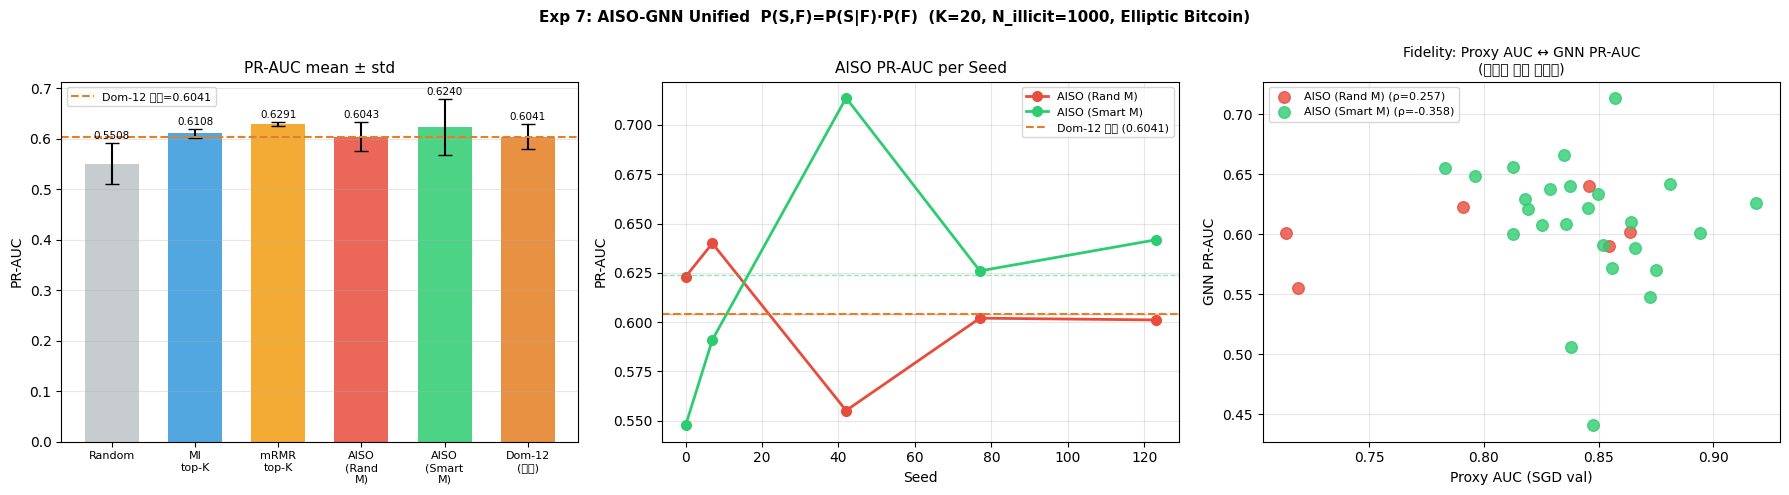

→ exp7_results.png 저장


In [8]:
colors_map = {
    'Random':           '#bdc3c7',
    'MI top-K':         '#3498db',
    'mRMR top-K':       '#f39c12',
    'AISO (Rand M)':    '#e74c3c',
    'AISO (Smart M)':   '#2ecc71',
    'Dom-12 (기준)':     '#e67e22',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (1) PR-AUC 바 차트 ───────────────────────────────────────
display_order = METHOD_ORDER + ['Dom-12 (기준)']
means, stds, cols = [], [], []
for m in display_order:
    if m == 'Dom-12 (기준)':
        means.append(BASELINE_DOM12); stds.append(BASELINE_STD12)
    else:
        means.append(summary[m]['PRAUC_mean'])
        stds.append(summary[m]['PRAUC_std'])
    cols.append(colors_map.get(m, '#95a5a6'))

x = np.arange(len(display_order))
axes[0].bar(x, means, yerr=stds, capsize=5, color=cols, alpha=0.85, width=0.65)
axes[0].axhline(BASELINE_DOM12, color='#e67e22', linestyle='--', linewidth=1.5,
                label=f'Dom-12 기준={BASELINE_DOM12:.4f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n') for m in display_order], fontsize=8)
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('PR-AUC mean ± std', fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis='y')
for xi, (mv, sv) in enumerate(zip(means, stds)):
    axes[0].text(xi, mv + sv + 0.004, f'{mv:.4f}', ha='center', va='bottom', fontsize=7.5)

# ── (2) Seed별 PR-AUC 궤적 ──────────────────────────────────
for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
    vals = [r['PR-AUC'] for r in all_results[mname]]
    col  = colors_map[mname]
    axes[1].plot(SEEDS, vals, 'o-', color=col, label=mname, linewidth=2, markersize=7)
    axes[1].axhline(np.mean(vals), color=col, linestyle='--', alpha=0.5, linewidth=1)
axes[1].axhline(BASELINE_DOM12, color='#e67e22', linestyle='--', linewidth=1.5,
                label=f'Dom-12 기준 ({BASELINE_DOM12:.4f})')
axes[1].set_xlabel('Seed'); axes[1].set_ylabel('PR-AUC')
axes[1].set_title('AISO PR-AUC per Seed', fontsize=11)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# ── (3) Fidelity: Proxy AUC vs GNN PR-AUC ───────────────────
for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
    pairs = fidelity_all.get(mname, [])
    if not pairs:
        continue
    px = [p[0] for p in pairs]; gy = [p[1] for p in pairs]
    rho = spearman_results.get(mname, (0,))[0]
    axes[2].scatter(px, gy, color=colors_map[mname], s=70, alpha=0.8, zorder=5,
                    label=f'{mname} (ρ={rho:.3f})')
axes[2].set_xlabel('Proxy AUC (SGD val)')
axes[2].set_ylabel('GNN PR-AUC')
axes[2].set_title('Fidelity: Proxy AUC ↔ GNN PR-AUC\n(리뷰어 방어 데이터)', fontsize=10)
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(
    f'Exp 7: AISO-GNN Unified  P(S,F)=P(S|F)·P(F)  '
    f'(K={K_SELECT}, N_illicit={N_ILLICIT}, Elliptic Bitcoin)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('exp7_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ exp7_results.png 저장')

---
## 11. 논문 기여 정리 (Ablation 해석)

| 조건 | 피처 선택 | 노드 선택 | PR-AUC |
|------|-----------|-----------|--------|
| Random | 랜덤 | 랜덤 | ? |
| MI top-K | MI | Feature-cond | ? |
| mRMR top-K | mRMR | Feature-cond | ? |
| AISO (Rand M) | AISO | Feature-cond | ? |
| **AISO (Smart M)** | **AISO+Smart** | **Feature-cond** | **?** |
| [기준] Dom-12 | 수동 | AISO | 0.6041 |

**읽는 법**:
- Random vs MI/mRMR → Feature-conditioned scoring 효과
- MI vs AISO(Rand) → AISO 탐색 효과
- AISO(Rand) vs AISO(Smart) → Smart M 효과
- vs Dom-12 → 수동 설계 제거 후 성능 변화

In [9]:
print('=== 논문용 Ablation Table ===')
print(f'{"모델":<22} {"피처 선택":<14} {"노드 선택":<18} {"PR-AUC":>8} {"±std":>7}')
print('=' * 75)

rows = [
    ('Random',         '랜덤',         '랜덤'),
    ('MI top-K',       'MI',          'Feature-cond'),
    ('mRMR top-K',     'mRMR',        'Feature-cond'),
    ('AISO (Rand M)',  'AISO',        'Feature-cond'),
    ('AISO (Smart M)', 'AISO+Smart',  'Feature-cond'),
]
for mname, fs, ns in rows:
    s = summary.get(mname, {})
    pr = s.get('PRAUC_mean', 0)
    st = s.get('PRAUC_std',  0)
    flag = '★' if pr > BASELINE_DOM12 else ''
    print(f'  {mname:<20} {fs:<14} {ns:<18} {pr:>8.4f} {st:>7.4f} {flag}')

print('-' * 75)
print(f'  {"[기준] Dom-12":<20} {"수동":<14} {"AISO":<18} '
      f'{BASELINE_DOM12:>8.4f} {BASELINE_STD12:>7.4f}  ← Exp 1b')
print('=' * 75)

# Spearman 요약
print('\n=== Fidelity 요약 ===')
for mname, (rho, pval, pairs) in spearman_results.items():
    print(f'  {mname}: ρ = {rho:.4f}  (p={pval:.4f})  n={len(pairs)}')

=== 논문용 Ablation Table ===
모델                     피처 선택          노드 선택                PR-AUC    ±std
  Random               랜덤             랜덤                   0.5508  0.0414 
  MI top-K             MI             Feature-cond         0.6108  0.0086 ★
  mRMR top-K           mRMR           Feature-cond         0.6291  0.0038 ★
  AISO (Rand M)        AISO           Feature-cond         0.6043  0.0285 ★
  AISO (Smart M)       AISO+Smart     Feature-cond         0.6240  0.0553 ★
---------------------------------------------------------------------------
  [기준] Dom-12          수동             AISO                 0.6041  0.0250  ← Exp 1b

=== Fidelity 요약 ===
  AISO (Rand M): ρ = 0.2571  (p=0.6228)  n=6
  AISO (Smart M): ρ = -0.3585  (p=0.0785)  n=25


=== Proxy Filtering Efficacy: E[GNN | proxy_high] vs E[GNN | proxy_low] ===

AISO (Rand M) (n=6):
  proxy ≤ 0.7369 (bottom 25%): GNN = 0.5781 ± 0.0230  (n=2)
  proxy mid:                      GNN = 0.6315 ± 0.0085  (n=2)
  proxy ≥ 0.8523 (top 25%):    GNN = 0.5961 ± 0.0059  (n=2)
  Δ(high−low) = +0.0179
  → proxy가 coarse discriminator 역할 수행 (filtering utility 존재)

AISO (Smart M) (n=25):
  proxy ≤ 0.8251 (bottom 25%): GNN = 0.6311 ± 0.0210  (n=7)
  proxy mid:                      GNN = 0.6028 ± 0.0721  (n=11)
  proxy ≥ 0.8642 (top 25%):    GNN = 0.5979 ± 0.0299  (n=7)
  Δ(high−low) = -0.0331
  → 역전 (proxy high → GNN low, anti-correlated)



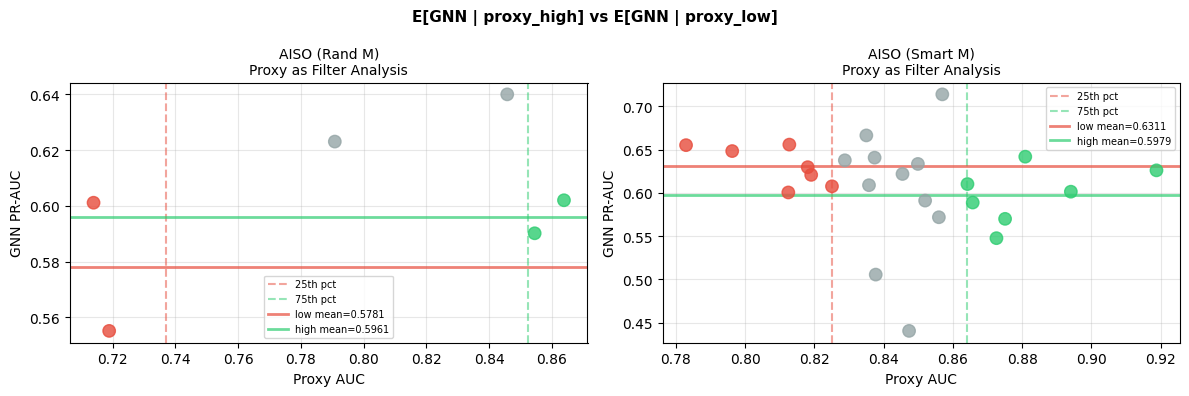

→ exp7_proxy_filter.png 저장


In [10]:
print('=== Proxy Filtering Efficacy: E[GNN | proxy_high] vs E[GNN | proxy_low] ===\n')

for mname in ['AISO (Rand M)', 'AISO (Smart M)']:
    pairs = fidelity_all.get(mname, [])
    if len(pairs) < 4:
        print(f'{mname}: 데이터 부족\n')
        continue

    px = np.array([p[0] for p in pairs])
    gy = np.array([p[1] for p in pairs])

    p25 = np.percentile(px, 25)
    p75 = np.percentile(px, 75)

    low_mask  = px <= p25
    high_mask = px >= p75
    mid_mask  = ~low_mask & ~high_mask

    gnn_low  = gy[low_mask]
    gnn_mid  = gy[mid_mask]
    gnn_high = gy[high_mask]

    delta = np.mean(gnn_high) - np.mean(gnn_low)

    print(f'{mname} (n={len(pairs)}):')
    print(f'  proxy ≤ {p25:.4f} (bottom 25%): GNN = {np.mean(gnn_low):.4f} ± {np.std(gnn_low):.4f}  (n={low_mask.sum()})')
    print(f'  proxy mid:                      GNN = {np.mean(gnn_mid):.4f} ± {np.std(gnn_mid):.4f}  (n={mid_mask.sum()})')
    print(f'  proxy ≥ {p75:.4f} (top 25%):    GNN = {np.mean(gnn_high):.4f} ± {np.std(gnn_high):.4f}  (n={high_mask.sum()})')
    print(f'  Δ(high−low) = {delta:+.4f}')

    if delta > 0.01:
        print(f'  → proxy가 coarse discriminator 역할 수행 (filtering utility 존재)')
    elif delta > -0.01:
        print(f'  → 차이 미미 (proxy filtering 효과 불분명)')
    else:
        print(f'  → 역전 (proxy high → GNN low, anti-correlated)')
    print()

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mname in zip(axes, ['AISO (Rand M)', 'AISO (Smart M)']):
    pairs = fidelity_all.get(mname, [])
    if not pairs:
        continue
    px = np.array([p[0] for p in pairs])
    gy = np.array([p[1] for p in pairs])
    p25, p75 = np.percentile(px, 25), np.percentile(px, 75)

    colors = np.where(px <= p25, '#e74c3c',
             np.where(px >= p75, '#2ecc71', '#95a5a6'))
    ax.scatter(px, gy, c=colors, s=80, alpha=0.8, zorder=5)
    ax.axvline(p25, color='#e74c3c', linestyle='--', alpha=0.5, label='25th pct')
    ax.axvline(p75, color='#2ecc71', linestyle='--', alpha=0.5, label='75th pct')

    # 그룹 평균 수평선
    for mask, color, label in [
        (px <= p25, '#e74c3c', f'low mean={gy[px<=p25].mean():.4f}'),
        (px >= p75, '#2ecc71', f'high mean={gy[px>=p75].mean():.4f}'),
    ]:
        ax.axhline(gy[mask].mean(), color=color, linewidth=2, alpha=0.7, label=label)

    ax.set_xlabel('Proxy AUC'); ax.set_ylabel('GNN PR-AUC')
    ax.set_title(f'{mname}\nProxy as Filter Analysis', fontsize=10)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('E[GNN | proxy_high] vs E[GNN | proxy_low]', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('exp7_proxy_filter.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ exp7_proxy_filter.png 저장')

In [ ]:
from pathlib import Path
import pandas as pd

p = Path('exp7_diversity_log.csv')
if not p.exists():
    print('exp7_diversity_log.csv 없음: 먼저 셀 7(로그 분석+CSV Export)까지 실행 필요')
else:
    d = pd.read_csv(p)
    print('rows =', len(d))
    print('methods =', sorted(d['method'].dropna().unique().tolist()))
    print('\n[mask_jaccard_mean 전체 통계]')
    print(d['mask_jaccard_mean'].describe())

    closest = d.iloc[(d['mask_jaccard_mean'] - 0.135).abs().argsort()[:10]][
        ['method','seed','generation','mask_jaccard_mean','node_jaccard_mean']
    ]
    print('\n[0.135 근접 상위 10개]')
    print(closest.to_string(index=False))

    exact = d[d['mask_jaccard_mean'].round(6) == 0.135]
    print(f"\nmask_jaccard_mean == 0.135 개수: {len(exact)}")

    by_method = d.groupby('method')['mask_jaccard_mean'].agg(['mean','min','max']).sort_values('mean')
    print('\n[method별 mask_jaccard_mean]')
    print(by_method.to_string())